In [1]:
!pip install torch torchaudio diffusers transformers accelerate faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 13.2 MB/s eta 0:00:00


In [2]:
import torch
import torchaudio
import os
import numpy as np
from diffusers.models import AutoencoderOobleck
import gc

def load_standalone_vae(device="cuda"):
    print("Downloading and loading 1D VAE directly via diffusers...")
    # This automatically downloads just the 'vae' subfolder from the HF repo
    vae = AutoencoderOobleck.from_pretrained(
        "ACE-Step/Ace-Step1.5",
        subfolder="vae",
        torch_dtype=torch.float32 # Use float32 to prevent underflow in 1D convolutions
    )
    vae.to(device)
    vae.eval()
    return vae

def process_audio_for_oobleck(file_path, target_sr=48000, device="cuda"):
    """Prepares audio exactly as the ACE-Step tiled_encode expects."""
    waveform, sr = torchaudio.load(file_path)

    # Resample to 48kHz
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)

    # Ensure Stereo (Oobleck expects 2 channels)
    if waveform.shape[0] == 1:
        waveform = waveform.repeat(2, 1)
    elif waveform.shape[0] > 2:
        waveform = waveform[:2, :]

    # Add batch dimension: [1, 2, sequence_length]
    waveform = waveform.unsqueeze(0).to(device)
    return waveform

def extract_track_embedding(vae, waveform, chunk_duration_sec=10, sr=48000):
    """
    Passes audio through the VAE in manageable chunks to prevent CUDA OOM,
    then pools the result into a single 64-D vector.
    """
    chunk_size = int(chunk_duration_sec * sr)
    latents_list = []

    with torch.no_grad():
        # Split the waveform into smaller temporal chunks (e.g., 10 seconds each)
        for i in range(0, waveform.shape[-1], chunk_size):
            chunk = waveform[:, :, i : i + chunk_size]

            # Skip tiny tail-end fragments (less than 1 second) to prevent tensor shape errors
            if chunk.shape[-1] < sr:
                continue

            # Encode the chunk
            latent = vae.encode(chunk).latent_dist.mode()
            latents_list.append(latent)

            # Free chunk memory immediately
            del chunk
            torch.cuda.empty_cache()

    # Stitch the latents back together along the temporal dimension (dim=2)
    full_latent = torch.cat(latents_list, dim=2)

    # Apply Mean Pooling across time (dim=2) to get the overall acoustic "vibe"
    pooled_vector = full_latent.mean(dim=2).squeeze(0)

    final_array = pooled_vector.cpu().numpy()

    # Free the large combined tensor
    del full_latent, latents_list
    torch.cuda.empty_cache()

    return final_array



Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = load_standalone_vae(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/337M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [4]:
def main():
    #device = "cuda" if torch.cuda.is_available() else "cpu"
    #vae = load_standalone_vae(device)

    # Example Usage:
    # 1. Fetch MTG-Jamendo 30s chunk
    test_audio_path = "sample.wav"
    waveform = process_audio_for_oobleck(test_audio_path, device=device)
    embedding = extract_track_embedding(vae, waveform)
    print(f"Final FAISS-ready Embedding Shape: {embedding.shape}") # (64,)

    print(embedding)

if __name__ == "__main__":
    main()

Final FAISS-ready Embedding Shape: (64,)
[-0.2833847  -0.43879825 -0.5751688  -0.48131612  0.33146873  0.20725869
 -0.20066072 -0.33597752 -0.22748259  0.11572639 -0.17007282  0.11145275
 -0.05675904  2.4433053  -1.1467763   0.04345514 -0.8620715   0.02962967
 -0.00804338 -2.1868336  -0.13576019  0.31078175  0.46225545  0.11075731
 -0.34108043 -0.04252258 -0.3822572   0.9616089  -0.06266788 -0.6232491
  0.60284007  0.21863651 -0.02499879  0.09744589 -0.15928523  0.28883004
  0.12907605 -0.40305793  0.00564619 -0.33948204  0.05457373  0.03144308
 -0.82649064 -0.2688673  -0.24090776 -0.22884175  0.18229513 -0.35929707
 -0.7196694  -0.6853439  -0.2869159   0.50200635  0.16665211  0.05793559
 -0.18764412 -0.23104683 -1.4940114  -0.1007099   0.5756404   0.3362683
 -0.33269233 -0.0139826   0.5517541   0.05760214]


## Quickly smoke-test by running a reconstruction to check if the encoder is working as expected

### Test 1: The Round-Trip Audio Reconstruction
> Before pooling the latents into a 64-D vector, decode the raw sequence back into an audio waveform. This proves the AutoencoderOobleck is correctly configured and the sample rate / channel setups are right.

In [5]:
import torchaudio

device = "cuda" if torch.cuda.is_available() else "cpu"
vae = load_standalone_vae(device)

def test_reconstruction(vae, waveform, output_path="reconstructed.wav"):
    with torch.no_grad():
        # 1. Encode to latents
        latents = vae.encode(waveform).latent_dist.mode()

        # 2. Decode back to audio
        reconstructed_waveform = vae.decode(latents).sample

        # 3. Save to disk
        torchaudio.save(
            output_path,
            reconstructed_waveform.squeeze(0).cpu(),
            sample_rate=48000
        )
    print(f"Saved reconstruction to {output_path}. Give it a listen!")


waveform_test = process_audio_for_oobleck("sample.wav", device=device)
test_reconstruction(vae, waveform_test)

# Display a quick waveform/spectrogram for both the original sample and the reconstructed sample side-by-side


Saved reconstruction to reconstructed.wav. Give it a listen!


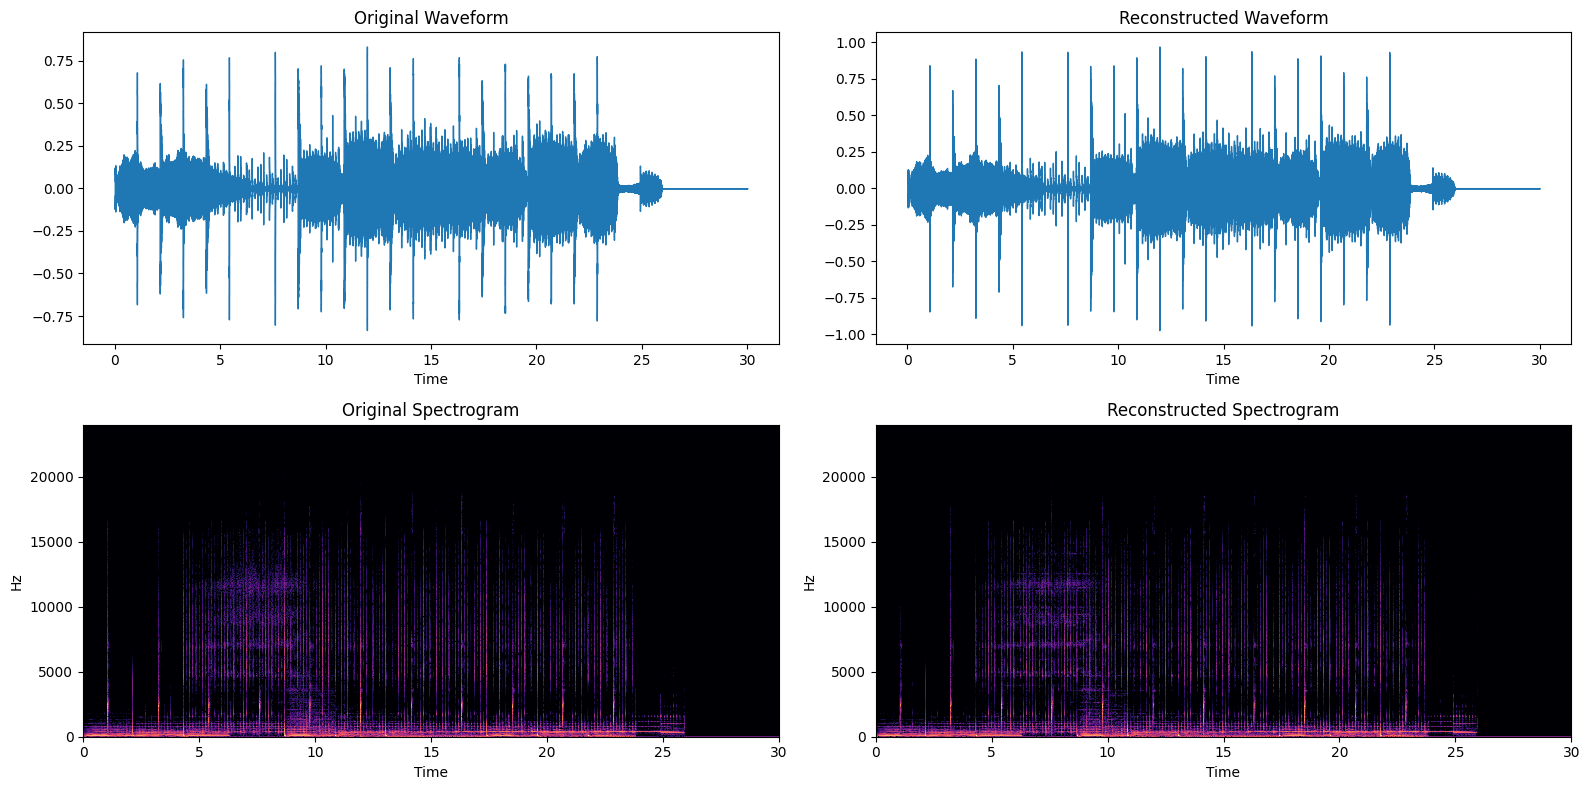

In [6]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

def plot_comparison(original_path, reconstructed_path):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    # Load audio
    y_orig, sr = librosa.load(original_path, sr=48000)
    y_recon, _ = librosa.load(reconstructed_path, sr=48000)

    # Waveforms
    librosa.display.waveshow(y_orig, sr=sr, ax=axes[0, 0])
    axes[0, 0].set_title('Original Waveform')

    librosa.display.waveshow(y_recon, sr=sr, ax=axes[0, 1])
    axes[0, 1].set_title('Reconstructed Waveform')

    # Spectrograms
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 0])
    axes[1, 0].set_title('Original Spectrogram')

    D_recon = librosa.amplitude_to_db(np.abs(librosa.stft(y_recon)), ref=np.max)
    librosa.display.specshow(D_recon, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, 1])
    axes[1, 1].set_title('Reconstructed Spectrogram')

    plt.tight_layout()
    plt.show()

plot_comparison('sample.wav', 'reconstructed.wav')

## Test 2: The Acoustic Distance & PCA Matrix

Running a quick Principal Component Analysis (PCA) to verify that distinct acoustic profiles natively repel each other in the latent space.

> grab 3-4 groups of music samples with extremely distinct audio styles (like: group1: classical, group2: ambient, group3: hip-hop, etc) and check if the embeddings are closer to the samples from the same group and far-apart for the samples belonging to the same group, or even apply PCA for 3 dimensional visualization.

In [7]:
!pip install yt-dlp
!apt-get install -y ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [8]:
import os
from yt_dlp import YoutubeDL

# Define your genres and their respective URLs
music_data = {
    "classical": [
        "https://www.youtube.com/watch?v=q9bU12gXUyM", #beethoven fur elise
        "https://www.youtube.com/watch?v=rrk-zuuc77U", # mozart turkish march
        "https://www.youtube.com/watch?v=9E6b3swbnWg" # chopin nocturne
    ],
    "hiphop": [
        "https://www.youtube.com/watch?v=5qm8PH4xAss", # 50 cent
        "https://www.youtube.com/watch?v=PBwAxmrE194", # wu tang
        "https://www.youtube.com/watch?v=_CL6n0FJZpk" # dr dre
    ],
    "metal": [
        "https://www.youtube.com/watch?v=5abamRO41fE", # slipknot
        "https://www.youtube.com/watch?v=iywaBOMvYLI", # system of a down
        "https://www.youtube.com/watch?v=E0ozmU9cJDg" # metallica
    ]
}

In [11]:
def download_genre_set(data, base_path='smoke_test_audio'):
    for genre, urls in data.items():
        # Create a subfolder for each genre (e.g., audio_dataset/classical)
        genre_folder = os.path.join(base_path, genre)
        if not os.path.exists(genre_folder):
            os.makedirs(genre_folder)

        print(f"\n--- Starting download for Genre: {genre.upper()} ---")

        for index, url in enumerate(urls):
            # Define output filename: e.g., audio_dataset/classical/classical_song_1
            output_filename = f"{genre}_song_{index + 1}"
            output_path = os.path.join(genre_folder, output_filename)

            ydl_opts = {
                'format': 'bestaudio/best',
                'postprocessors': [{
                    'key': 'FFmpegExtractAudio',
                    'preferredcodec': 'wav',
                    'preferredquality': '192',
                }],
                'outtmpl': output_path,
                'quiet': True, # Reduces console clutter during bulk downloads
                'no_warnings': True
            }

            try:
                with YoutubeDL(ydl_opts) as ydl:
                    ydl.download([url])
                print(f"✅ Downloaded: {genre}/{output_filename}.wav")
            except Exception as e:
                print(f"❌ Failed to download {url}: {e}")

# Run the loop
download_genre_set(music_data)


--- Starting download for Genre: CLASSICAL ---
✅ Downloaded: classical/classical_song_1.wav
✅ Downloaded: classical/classical_song_2.wav
✅ Downloaded: classical/classical_song_3.wav

--- Starting download for Genre: HIPHOP ---
✅ Downloaded: hiphop/hiphop_song_1.wav
✅ Downloaded: hiphop/hiphop_song_2.wav
✅ Downloaded: hiphop/hiphop_song_3.wav

--- Starting download for Genre: METAL ---
✅ Downloaded: metal/metal_song_1.wav
✅ Downloaded: metal/metal_song_2.wav
✅ Downloaded: metal/metal_song_3.wav


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



Extracting Latents...
Extracted: classical_song_1.wav -> Shape: (64,)
Extracted: classical_song_2.wav -> Shape: (64,)
Extracted: classical_song_3.wav -> Shape: (64,)


/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'AutoencoderOobleck' object attribute is deprecated. Please access '__iter__' over 'AutoencoderOobleck's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):


Extracted: hiphop_song_1.wav -> Shape: (64,)


/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'AutoencoderOobleck' object attribute is deprecated. Please access '__iter__' over 'AutoencoderOobleck's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):


Extracted: hiphop_song_2.wav -> Shape: (64,)
Extracted: hiphop_song_3.wav -> Shape: (64,)
Extracted: metal_song_1.wav -> Shape: (64,)
Extracted: metal_song_2.wav -> Shape: (64,)
Extracted: metal_song_3.wav -> Shape: (64,)

--- Cosine Similarity Matrix ---
              classic  classic  classic  hiphop_  hiphop_  hiphop_  metal_s  metal_s  metal_s
  classical_    1.000    0.491    0.744    0.362    0.289    0.048   -0.171    0.037   -0.099 
  classical_    0.491    1.000    0.323    0.392   -0.043   -0.003   -0.459   -0.093   -0.263 
  classical_    0.744    0.323    1.000    0.362    0.109    0.030   -0.178    0.212   -0.145 
  hiphop_son    0.362    0.392    0.362    1.000    0.297   -0.105    0.122    0.486    0.194 
  hiphop_son    0.289   -0.043    0.109    0.297    1.000    0.223    0.453    0.437    0.558 
  hiphop_son    0.048   -0.003    0.030   -0.105    0.223    1.000    0.131   -0.109    0.030 
  metal_song   -0.171   -0.459   -0.178    0.122    0.453    0.131    1.000    0

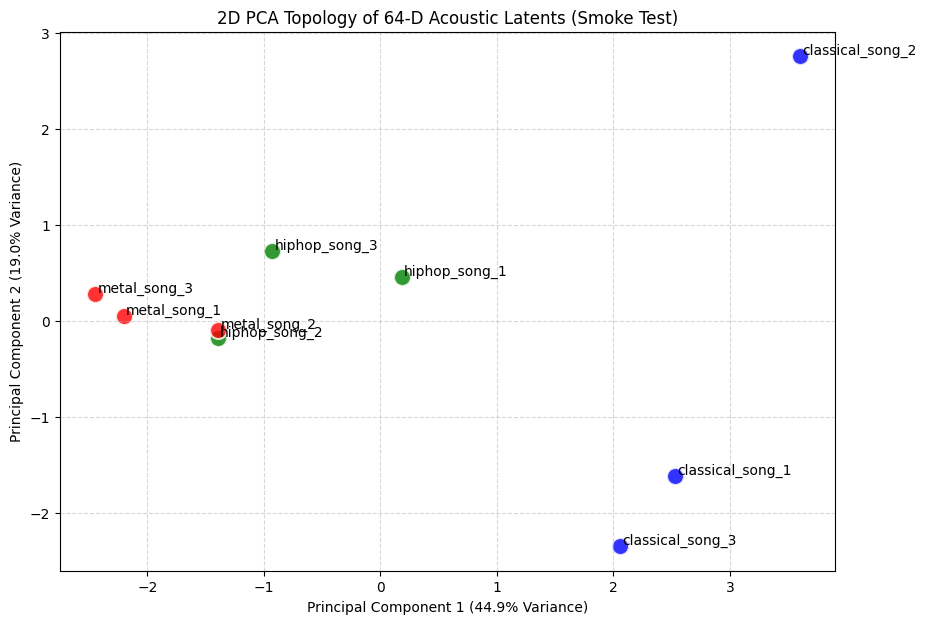

In [12]:
# Cell 2: VAE Extraction and SML Topology Evaluation
#!pip install torch torchaudio diffusers transformers accelerate scikit-learn matplotlib

import torch
import torchaudio
import os
import numpy as np
from diffusers.models import AutoencoderOobleck
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 2. Process Folders ---
device = "cuda" if torch.cuda.is_available() else "cpu"
vae = load_standalone_vae(device)

embeddings = []
labels = []
output_dir = "smoke_test_audio"

print("\nExtracting Latents...")
for genre in sorted(os.listdir(output_dir)):
    genre_path = os.path.join(output_dir, genre)
    if os.path.isdir(genre_path):
        for file_name in sorted(os.listdir(genre_path)):
            if file_name.endswith(".wav"):
                file_path = os.path.join(genre_path, file_name)
                waveform = process_audio_for_oobleck(file_path, device=device)
                emb = extract_track_embedding(vae, waveform)
                embeddings.append(emb)
                labels.append(file_name.replace(".wav", ""))
                print(f"Extracted: {file_name} -> Shape: {emb.shape}")

# --- 3. SML Evaluation Matrix ---
matrix = np.vstack(embeddings)

# A: Cosine Similarity Matrix
similarity = cosine_similarity(matrix)
print("\n--- Cosine Similarity Matrix ---")
print(f"{'':>12} " + " ".join([f"{l[:7]:>8}" for l in labels]))
for i in range(len(labels)):
    row_str = f"{labels[i][:10]:>12} "
    for j in range(len(labels)):
        row_str += f"{similarity[i][j]:8.3f} "
    print(row_str)

# B: PCA Visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(matrix)

plt.figure(figsize=(10, 7))
# Group colors by the first 5 letters of the genre
genre_colors = {"class": "blue", "hipho": "green", "metal": "red"}

for i, label in enumerate(labels):
    color_key = label[:5]
    color = genre_colors.get(color_key, 'black')
    plt.scatter(reduced[i, 0], reduced[i, 1], c=color, s=150, alpha=0.8, edgecolors='white', linewidth=1.5)
    plt.annotate(label, (reduced[i, 0]+0.02, reduced[i, 1]+0.02), fontsize=10)

plt.title("2D PCA Topology of 64-D Acoustic Latents (Smoke Test)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.grid(True, linestyle='--', alpha=0.5)

print(f"\nTotal Variance Explained by 2D mapping: {sum(pca.explained_variance_ratio_)*100:.1f}%")
plt.show()


Total Variance Explained by 3D mapping: 79.1%


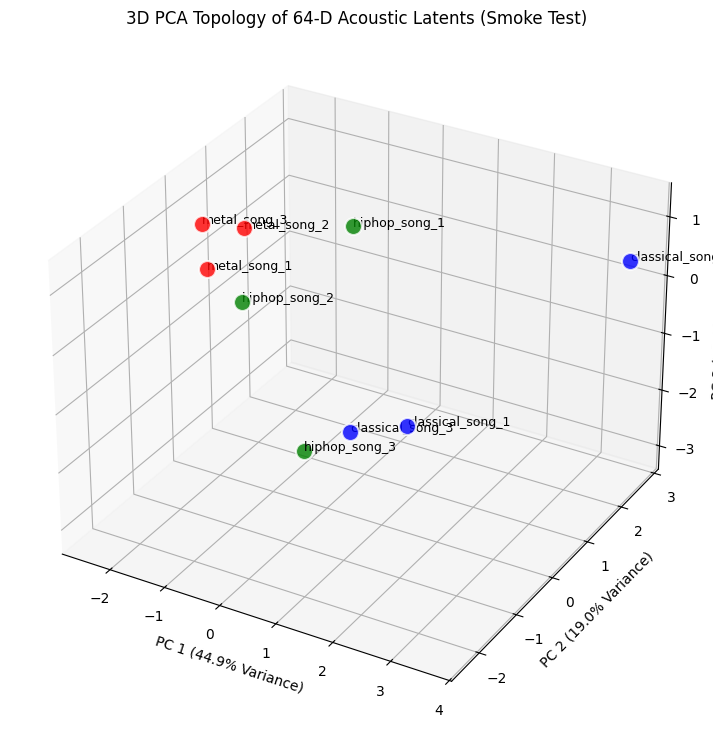

In [13]:
from mpl_toolkits.mplot3d import Axes3D

# B: 3D PCA Visualization
pca = PCA(n_components=3)
reduced = pca.fit_transform(matrix)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Group colors by the first 5 letters of the genre
genre_colors = {"class": "blue", "hipho": "green", "metal": "red"}

for i, label in enumerate(labels):
    color_key = label[:5]
    color = genre_colors.get(color_key, 'black')
    ax.scatter(reduced[i, 0], reduced[i, 1], reduced[i, 2], c=color, s=150, alpha=0.8, edgecolors='white', linewidth=1.5)
    ax.text(reduced[i, 0], reduced[i, 1], reduced[i, 2], label, fontsize=9)

ax.set_title("3D PCA Topology of 64-D Acoustic Latents (Smoke Test)")
ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
ax.set_zlabel(f"PC 3 ({pca.explained_variance_ratio_[2]*100:.1f}% Variance)")

print(f"\nTotal Variance Explained by 3D mapping: {sum(pca.explained_variance_ratio_)*100:.1f}%")
plt.show()